In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.v2 as tfs
from PIL import Image
import torch.utils.data as data
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class SegmentDataset(data.Dataset):
    def __init__(self, path, transforms_img=None, transforms_masks=None):
        self.path = path
        self.transforms_img = transforms_img
        self.transforms_masks = transforms_masks
        
        path = os.path.join(self.path, "images")
        list_files = os.listdir(path)
        self.images = []
        self.lenght = len(list_files)
        for files in list_files:
            self.images.append(os.path.join(path, files))

        path = os.path.join(self.path, "masks")
        list_masks = os.listdir(path)
        self.masks = []
        for mask in list_masks:
            self.masks.append(os.path.join(path, mask))

    def __getitem__(self, item):
        path_img, path_mask = self.images[item], self.masks[item]
        
        img = Image.open(path_img).convert("RGB")
        mask = Image.open(path_mask).convert("L")
        
        if self.transforms_img:
            img = self.transforms_img(img)
        
        if self.transforms_masks:
            mask = self.transforms_masks(mask)
            mask[mask < 250] = 1
            mask[mask >= 250] = 0
        
        return img, mask

    def __len__(self):
        return self.lenght

In [3]:
class UNetModel(nn.Module):
    class _TwoConvLayers(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.model = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_channels),
                nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_channels)
            )
        def forward(self, x):
            return self.model(x)
    
    
    class _EncoderBlock(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.block = UNetModel._TwoConvLayers(in_channels, out_channels)
            self.max_pool = nn.MaxPool2d(2)
        def forward(self, x):
            x = self.block(x)
            y = self.max_pool(x)
            return y, x
    
    
    class _DecoderBlock(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.conv_t = nn.ConvTranspose2d(in_channels, out_channels, 2, 2, 0)
            self.block = UNetModel._TwoConvLayers(in_channels, out_channels)
        def forward(self, x, y):
            x = self.conv_t(x)
            x = torch.cat([x, y], dim=1)
            x = self.block(x)
            return x
    
    
    def __init__(self):
        super().__init__()
        self.enc_block1 = UNetModel._EncoderBlock(3, 64)
        self.enc_block2 = UNetModel._EncoderBlock(64, 128)
        self.enc_block3 = UNetModel._EncoderBlock(128, 256)
        self.enc_block4 = UNetModel._EncoderBlock(256, 512)
        
        self.bottleneck = UNetModel._TwoConvLayers(512, 1024)
        
        self.dec_block1 = UNetModel._DecoderBlock(1024, 512)
        self.dec_block2 = UNetModel._DecoderBlock(512, 256)
        self.dec_block3 = UNetModel._DecoderBlock(256, 128)
        self.dec_block4 = UNetModel._DecoderBlock(128, 64)
        
        self.out = nn.Conv2d(64, 1, 1, 1, 0)
    
    
    def forward(self, x):
        x ,y1 = self.enc_block1(x)
        x, y2 = self.enc_block2(x)
        x, y3 = self.enc_block3(x)
        x, y4 = self.enc_block4(x)
        
        x = self.bottleneck(x)
        
        x = self.dec_block1(x, y4)
        x = self.dec_block2(x, y3)
        x = self.dec_block3(x, y2)
        x = self.dec_block4(x, y1)
        
        return self.out(x)

In [4]:
class SoftDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, logistic, targets):
        num = targets.size(0)
        probs = nn.functional.sigmoid(logistic)
        m1 = probs.view(num, -1)
        m2 = targets.view(num, -1)
        intersection = (m1 * m2)
        score = (2 * intersection.sum(1) + 1) / (m1.sum(1) + m2.sum(1) + 1)
        score = 1 - score.sum()/num
        return score

In [5]:
tr_img = tfs.Compose([
    tfs.ToImage(),
    tfs.ToDtype(torch.float32, scale=True)
])

tr_mask = tfs.Compose([
    tfs.ToImage(),
    tfs.ToDtype(torch.float32)
])

d_train = SegmentDataset(r"dataset_seg", transforms_img=tr_img, transforms_masks=tr_mask)
train_data = data.DataLoader(d_train, batch_size=2, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNetModel()
model = model.to(device)

optimizer = optim.RMSprop(params=model.parameters(), lr=0.001)
loss_1 = nn.BCEWithLogitsLoss()
loss_2 = SoftDiceLoss()

epochs = 200
model.train()
best_val_loss = float('inf')
patience = 10
patience_counter = 0

for _e in range(epochs):
    loss_mean = 0
    lm_count = 0
    
    train_tqdm = tqdm(train_data, leave=True)
    for x_train, y_train in train_tqdm:
        x_train, y_train = x_train.to(device), y_train.to(device)
        predict = model(x_train)
        loss = loss_1(predict, y_train) + loss_2(predict, y_train)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        lm_count += 1
        loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean
        train_tqdm.set_description(f"Epoch [{_e+1}/{epochs}], loss_mean={loss_mean: .3f}")
    
    if loss_mean < best_val_loss:
        best_val_loss = loss_mean
        patience_counter = 0
        torch.save(model.state_dict(), 'model_seg.tar')
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f'Процесс прекращен на эпохе {_e + 1}')
        break

Epoch [47/200], loss_mean= 0.252: 100%|██████████| 10/10 [00:10<00:00,  1.07s/it]

Процесс прекращен на эпохе 47


*Для независимого запуска примеров работоспособности НС присутствует некоторое дублирование кода.* Как мы можем заметить из за очень маленького обьема выборки, НС не имеет хороших обощающих способностей, поэтому на сторонних данных она выдает хаотичный результат.

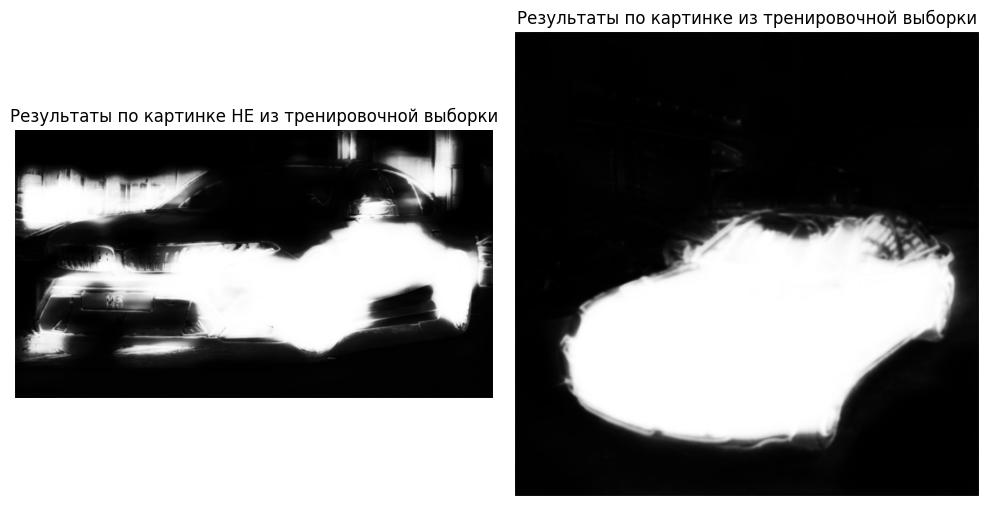

In [1]:
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms.v2 as tfs

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tr_img = tfs.Compose([
    tfs.ToImage(),
    tfs.ToDtype(torch.float32, scale=True)
])

class UNetModel(nn.Module):
    class _TwoConvLayers(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.model = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_channels),
                nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_channels)
            )
        def forward(self, x):
            return self.model(x)
    
    
    class _EncoderBlock(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.block = UNetModel._TwoConvLayers(in_channels, out_channels)
            self.max_pool = nn.MaxPool2d(2)
        def forward(self, x):
            x = self.block(x)
            y = self.max_pool(x)
            return y, x
    
    
    class _DecoderBlock(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.conv_t = nn.ConvTranspose2d(in_channels, out_channels, 2, 2, 0)
            self.block = UNetModel._TwoConvLayers(in_channels, out_channels)
        def forward(self, x, y):
            x = self.conv_t(x)
            x = torch.cat([x, y], dim=1)
            x = self.block(x)
            return x
    
    
    def __init__(self):
        super().__init__()
        self.enc_block1 = UNetModel._EncoderBlock(3, 64)
        self.enc_block2 = UNetModel._EncoderBlock(64, 128)
        self.enc_block3 = UNetModel._EncoderBlock(128, 256)
        self.enc_block4 = UNetModel._EncoderBlock(256, 512)
        
        self.bottleneck = UNetModel._TwoConvLayers(512, 1024)
        
        self.dec_block1 = UNetModel._DecoderBlock(1024, 512)
        self.dec_block2 = UNetModel._DecoderBlock(512, 256)
        self.dec_block3 = UNetModel._DecoderBlock(256, 128)
        self.dec_block4 = UNetModel._DecoderBlock(128, 64)
        
        self.out = nn.Conv2d(64, 1, 1, 1, 0)
    
    
    def forward(self, x):
        x ,y1 = self.enc_block1(x)
        x, y2 = self.enc_block2(x)
        x, y3 = self.enc_block3(x)
        x, y4 = self.enc_block4(x)
        
        x = self.bottleneck(x)
        
        x = self.dec_block1(x, y4)
        x = self.dec_block2(x, y3)
        x = self.dec_block3(x, y2)
        x = self.dec_block4(x, y1)
        
        return self.out(x)


model_train = UNetModel()
model_train = model_train.to(device)
weights = torch.load("model_seg.tar", weights_only=True)
model_train.load_state_dict(weights)
model_train.eval()

with torch.no_grad():
    img = Image.open(r"test_data/car.jpg").convert("RGB")
    img = tr_img(img).unsqueeze(0)
    img = img.to(device)

    p = model_train(img).squeeze(0)
    x = nn.functional.sigmoid(p.permute(1, 2, 0))
    x = x.cpu().detach().numpy() * 255
    x = np.clip(x, 0, 255).astype('uint8')

    img_train = Image.open(r"test_data/train_car.jpg").convert("RGB")
    img_train = tr_img(img_train).unsqueeze(0)
    img_train = img_train.to(device)

    p_train = model_train(img_train).squeeze(0)
    x_train = nn.functional.sigmoid(p_train.permute(1, 2, 0))
    x_train = x_train.cpu().detach().numpy() * 255
    x_train = np.clip(x_train, 0, 255).astype('uint8')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(x, cmap="gray")
axes[0].set_title("Результаты по картинке НЕ из тренировочной выборки")
axes[0].axis('off')

axes[1].imshow(x_train, cmap="gray")
axes[1].set_title("Результаты по картинке из тренировочной выборки")
axes[1].axis('off')

plt.tight_layout()
plt.show()